In [1]:
import tensorflow as tf
from tensorflow.keras import layers, models
from tensorflow.keras.applications import MobileNetV2
from tensorflow.keras.preprocessing.image import ImageDataGenerator, load_img, img_to_array
from tensorflow.keras import regularizers
from tensorflow.keras.callbacks import EarlyStopping, ModelCheckpoint
from pyswarm import pso
import numpy as np
from sklearn.model_selection import train_test_split
import os
import matplotlib.pyplot as plt
from PIL import Image


In [2]:
# Clear GPU memory
tf.keras.backend.clear_session()
# List all physical GPUs
gpus = tf.config.list_physical_devices('GPU')
if gpus:
    try:
        # Enable memory growth for each GPU
        for gpu in gpus:
            tf.config.experimental.set_memory_growth(gpu, True)
        print("GPU memory growth set successfully.")
    except RuntimeError as e:
        # Memory growth must be set before GPUs have been initialized
        print(e)
else:
    print("No GPU found.")

    


GPU memory growth set successfully.


In [3]:
# Function to parse MIAS info.txt file
def parse_mias_info(info_file):
    labels = {}
    if not os.path.exists(info_file):
        raise FileNotFoundError(f"Info file not found at: {info_file}")
    with open(info_file, 'r') as f:
        for line in f:
            parts = line.strip().split()
            if len(parts) >= 4:
                img_name = parts[0]
                severity = parts[3] if len(parts) > 3 else 'N'
                if severity in ['B', 'M']:
                    labels[img_name] = 0 if severity == 'B' else 1
    return labels


In [4]:
# Function to load and augment MIAS images
def load_and_augment_mias_data(image_dir, info_file, target_size=(192, 192), target_per_class=100):
    labels_dict = parse_mias_info(info_file)
    X, y = [], []
    datagen = ImageDataGenerator(
        rotation_range=45,
        width_shift_range=0.3,
        height_shift_range=0.3,
        shear_range=0.2,
        zoom_range=[0.7, 1.3],
        horizontal_flip=True,
        vertical_flip=True,
        brightness_range=[0.9, 1.1],
        preprocessing_function=lambda x: x + np.random.normal(0, 0.03, x.shape),
        fill_mode='nearest'
    )
    
    # Load original images
    for img_name in labels_dict.keys():
        img_path = os.path.join(image_dir, f"{img_name}.pgm")
        if os.path.exists(img_path):
            try:
                img = Image.open(img_path).convert('RGB')
                img = img.resize(target_size)
                img_array = img_to_array(img)
                img_array = tf.keras.applications.mobilenet_v2.preprocess_input(img_array)
                X.append(img_array)
                y.append(labels_dict[img_name])
            except Exception as e:
                print(f"Error loading image {img_path}: {e}")
        else:
            print(f"Image not found: {img_path}")
    
    X = np.array(X)
    y = np.array(y)
    
    if len(X) == 0:
        raise ValueError("No images were loaded. Check image_dir and info_file paths.")
    
    # Separate by class
    benign_idx = np.where(y == 0)[0]
    malignant_idx = np.where(y == 1)[0]
    X_benign, y_benign = X[benign_idx], y[benign_idx]
    X_malignant, y_malignant = X[malignant_idx], y[malignant_idx]
    
    print(f"Loaded Benign: {len(X_benign)}, Malignant: {len(X_malignant)}")
    
    # Augment to reach target_per_class
    def augment_images(X_class, y_class, target_count):
        current_count = len(X_class)
        if current_count == 0:
            raise ValueError("No images in this class to augment.")
        if current_count >= target_count:
            return X_class[:target_count], y_class[:target_count]
        X_aug = list(X_class)
        y_aug = list(y_class)
        it = datagen.flow(X_class, y_class, batch_size=1)
        while len(X_aug) < target_count:
            X_batch, y_batch = next(it)
            X_aug.append(X_batch[0])
            y_aug.append(y_batch[0])
        return np.array(X_aug[:target_count]), np.array(y_aug[:target_count])
    
    X_benign_aug, y_benign_aug = augment_images(X_benign, y_benign, target_per_class)
    X_malignant_aug, y_malignant_aug = augment_images(X_malignant, y_malignant, target_per_class)
    
    # Combine
    X_final = np.concatenate([X_benign_aug, X_malignant_aug])
    y_final = np.concatenate([y_benign_aug, y_malignant_aug])
    
    print(f"Final dataset: {len(X_final)} images")
    print(f"Shape of X: {X_final.shape}")
    print(f"Shape of y: {y_final.shape}")
    print(f"Label distribution: {np.bincount(y_final)}")
    
    return X_final, y_final


In [5]:
# Function to display sample images
def display_sample_images(X, y, num_samples=5, title="Sample Images"):
    X_display = (X + 1) * 127.5
    X_display = np.clip(X_display, 0, 255).astype(np.uint8)
    num_samples = min(num_samples, len(X))
    indices = np.random.choice(len(X), num_samples, replace=False)
    plt.figure(figsize=(15, 3))
    plt.suptitle(title)
    for i, idx in enumerate(indices):
        plt.subplot(1, num_samples, i + 1)
        plt.imshow(X_display[idx])
        label = "Malignant" if y[idx] == 1 else "Benign"
        plt.title(f"Label: {label}")
        plt.axis('off')
    plt.show()


In [6]:
# Define MobileNetV2 model
def create_mobilenetv2_model(learning_rate, dropout_rate, print_summary=False):
    base_model = MobileNetV2(weights='imagenet', include_top=False, input_shape=(192, 192, 3))
    for layer in base_model.layers:
        layer.trainable = True
    
    model = models.Sequential([
        base_model,
        layers.GlobalAveragePooling2D(),
        layers.BatchNormalization(),
        layers.Dense(256, activation='relu', kernel_regularizer=regularizers.l2(0.0001)),
        layers.Dropout(dropout_rate),
        layers.Dense(128, activation='relu', kernel_regularizer=regularizers.l2(0.0001)),
        layers.Dropout(dropout_rate / 2),
        layers.Dense(64, activation='relu', kernel_regularizer=regularizers.l2(0.0001)),
        layers.Dense(1, activation='sigmoid')
    ])
    
    optimizer = tf.keras.optimizers.Adam(learning_rate=learning_rate)
    model.compile(optimizer=optimizer, loss='binary_crossentropy', metrics=['accuracy'])
    
    if print_summary:
        model.summary()
    
    return model


Loaded Benign: 63, Malignant: 52
Final dataset: 200 images
Shape of X: (200, 192, 192, 3)
Shape of y: (200,)
Label distribution: [100 100]


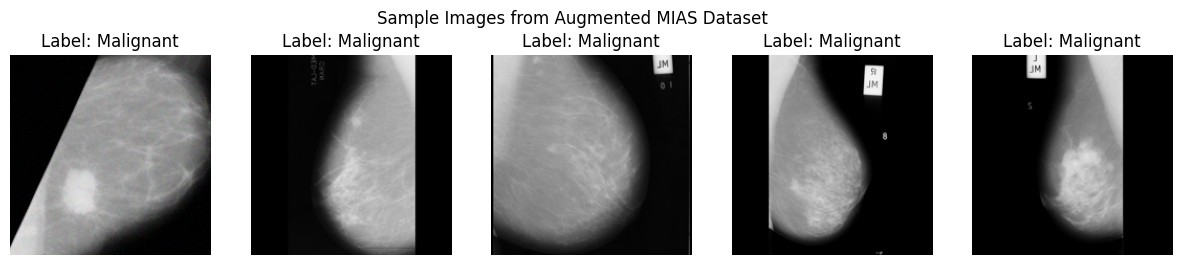

In [7]:
# Load and augment MIAS data
data_dir = r"archive/all-mias"  # Use raw string to handle backslashes
info_file = r"archive/Info.txt"  # Adjust path if Info.txt is in same dir
X, y = load_and_augment_mias_data(data_dir, info_file, target_per_class=100)

# Display sample images
display_sample_images(X, y, num_samples=5, title="Sample Images from Augmented MIAS Dataset")


In [8]:
if len(X) == 0:
    print("Stopping execution due to no data loaded.")
    exit()

# Split data
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, stratify=y, random_state=42)
X_train_pso, X_val_pso, y_train_pso, y_val_pso = train_test_split(X_train, y_train, test_size=0.2, 
                                                                 stratify=y_train, random_state=42)


In [9]:
# Calculate class weights
class_counts = np.bincount(y_train_pso)
total_samples = len(y_train_pso)
class_weights = {0: total_samples / (2 * class_counts[0]), 1: total_samples / (2 * class_counts[1])}
print("Class weights:", class_weights)


Class weights: {0: 1.0, 1: 1.0}


In [10]:
# Data augmentation for training
datagen = ImageDataGenerator(
    rotation_range=45,
    width_shift_range=0.3,
    height_shift_range=0.3,
    shear_range=0.2,
    zoom_range=[0.7, 1.3],
    horizontal_flip=True,
    vertical_flip=True,
    brightness_range=[0.9, 1.1],
    preprocessing_function=lambda x: x + np.random.normal(0, 0.03, x.shape),
    fill_mode='nearest'
)


In [11]:
# PSO objective function
def pso_objective(params):
    learning_rate, dropout_rate = params
    model = create_mobilenetv2_model(learning_rate, dropout_rate)
    history = model.fit(
        datagen.flow(X_train_pso, y_train_pso, batch_size=16),
        epochs=40,
        validation_data=(X_val_pso, y_val_pso),
        class_weight=class_weights,
        verbose=0
    )
    val_accuracy = max(history.history['val_accuracy'])
    print(f"PSO - LR: {learning_rate:.6f}, Dropout: {dropout_rate:.6f}, Val Acc: {val_accuracy:.4f}")
    tf.keras.backend.clear_session()
    return -val_accuracy


In [12]:
# Run PSO
lb = [0.000005, 0.05]
ub = [0.0001, 0.25]
best_params, best_score = pso(pso_objective, lb, ub, swarmsize=6, maxiter=5)
learning_rate, dropout_rate = best_params
print(f"Best PSO params: LR={learning_rate:.6f}, Dropout={dropout_rate:.6f}, Val Acc={-best_score:.4f}")


PSO - LR: 0.000031, Dropout: 0.164286, Val Acc: 0.5625
PSO - LR: 0.000047, Dropout: 0.079711, Val Acc: 0.5938
PSO - LR: 0.000072, Dropout: 0.142697, Val Acc: 0.7188
PSO - LR: 0.000097, Dropout: 0.213896, Val Acc: 0.5625
PSO - LR: 0.000079, Dropout: 0.140149, Val Acc: 0.5938
PSO - LR: 0.000096, Dropout: 0.245085, Val Acc: 0.6562
PSO - LR: 0.000005, Dropout: 0.082332, Val Acc: 0.4062
PSO - LR: 0.000092, Dropout: 0.050000, Val Acc: 0.6875
PSO - LR: 0.000042, Dropout: 0.100602, Val Acc: 0.5000
PSO - LR: 0.000073, Dropout: 0.191066, Val Acc: 0.5938
PSO - LR: 0.000041, Dropout: 0.050000, Val Acc: 0.7500
PSO - LR: 0.000079, Dropout: 0.230857, Val Acc: 0.6875
PSO - LR: 0.000005, Dropout: 0.050000, Val Acc: 0.5938
PSO - LR: 0.000100, Dropout: 0.050000, Val Acc: 0.6875
PSO - LR: 0.000037, Dropout: 0.066029, Val Acc: 0.6250
PSO - LR: 0.000046, Dropout: 0.119326, Val Acc: 0.6875
PSO - LR: 0.000022, Dropout: 0.050000, Val Acc: 0.7500
PSO - LR: 0.000058, Dropout: 0.170611, Val Acc: 0.7500
PSO - LR: 

In [13]:
# Triangular cyclic learning rate scheduler
def triangular_cyclic_lr(epoch, lr):
    cycle_length = 30
    max_lr = 0.0005
    min_lr = 0.000005
    step = (max_lr - min_lr) / (cycle_length // 2)
    cycle_pos = epoch % cycle_length
    if cycle_pos < (cycle_length // 2):
        return min_lr + step * cycle_pos
    else:
        return max_lr - step * (cycle_pos - cycle_length // 2)


In [17]:
# Final model training
final_model = create_mobilenetv2_model(learning_rate, dropout_rate, print_summary=True)

callbacks = [
    EarlyStopping(monitor='val_accuracy', patience=1000, restore_best_weights=True, mode='max'),
    ModelCheckpoint('best_model.h5', monitor='val_accuracy', save_best_only=True, mode='max', verbose=1),
    tf.keras.callbacks.LearningRateScheduler(triangular_cyclic_lr, verbose=1)
]

history = final_model.fit(
    datagen.flow(X_train, y_train, batch_size=20),
    epochs=1000,
    validation_data=(X_test, y_test),
    class_weight=class_weights,
    callbacks=callbacks,
    verbose=1
)


Model: "sequential_3"
_________________________________________________________________
 Layer (type)                Output Shape              Param #   
 mobilenetv2_1.00_192 (Funct  (None, 6, 6, 1280)       2257984   
 ional)                                                          
                                                                 
 global_average_pooling2d_3   (None, 1280)             0         
 (GlobalAveragePooling2D)                                        
                                                                 
 batch_normalization_3 (Batc  (None, 1280)             5120      
 hNormalization)                                                 
                                                                 
 dense_12 (Dense)            (None, 256)               327936    
                                                                 
 dropout_6 (Dropout)         (None, 256)               0         
                                                      

In [18]:
# Load the best model
final_model = tf.keras.models.load_model('best_model.h5')

# Evaluate
test_loss, test_accuracy = final_model.evaluate(X_test, y_test, verbose=1)
print(f"Final Test Accuracy: {test_accuracy:.4f}")


2/2 [==============================] - 1s 17ms/step - loss: 0.8095 - accuracy: 0.8750
Final Test Accuracy: 0.8750


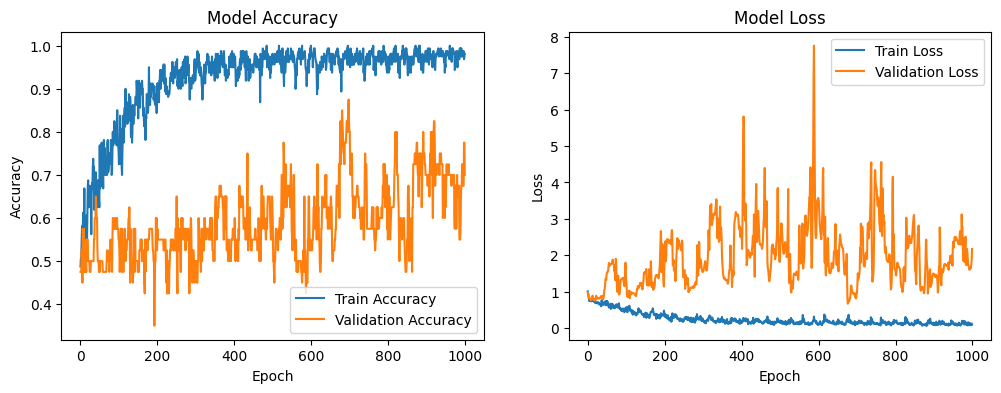

In [19]:
# Plot training history
plt.figure(figsize=(12, 4))
plt.subplot(1, 2, 1)
plt.plot(history.history['accuracy'], label='Train Accuracy')
plt.plot(history.history['val_accuracy'], label='Validation Accuracy')
plt.title('Model Accuracy')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.legend()
plt.subplot(1, 2, 2)
plt.plot(history.history['loss'], label='Train Loss')
plt.plot(history.history['val_loss'], label='Validation Loss')
plt.title('Model Loss')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend()
plt.show()


In [20]:
# Prediction function
def predict_image(image_path, model):
    img = load_img(image_path, target_size=(192, 192))
    img_array = img_to_array(img)
    img_display = img_array.copy()
    img_array = np.expand_dims(img_array, axis=0)
    img_array = tf.keras.applications.mobilenet_v2.preprocess_input(img_array)
    
    prediction = model.predict(img_array)[0][0]
    result = "Malignant" if prediction >= 0.5 else "Benign"
    confidence = prediction * 100 if prediction >= 0.5 else (1 - prediction) * 100
    
    plt.figure(figsize=(5, 5))
    plt.imshow(img_display.astype(np.uint8))
    plt.title(f"Predicted: {result} ({confidence:.2f}%)")
    plt.axis('off')
    plt.show()
    
    print(f"Prediction: {result}")
    print(f"Confidence: {confidence:.2f}%")
    return result, confidence


1/1 [==============================] - 1s 650ms/step


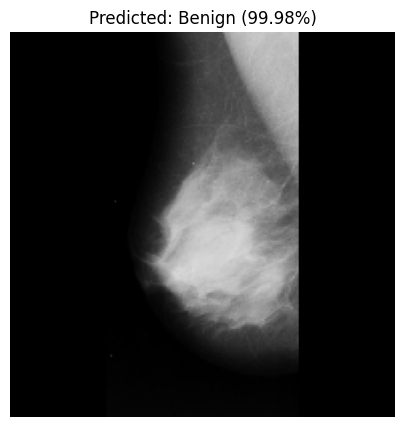

Prediction: Benign
Confidence: 99.98%


In [21]:
# Example prediction
image_path = r"archive/all-mias/mdb001.pgm"
result, confidence = predict_image(image_path, final_model)

# Save the final model
final_model.save('mobilenetv2_mias_benign_malignant.h5')
